# Tutorial 3 — Characterization: breaking the mass–inclination degeneracy

Detecting a moon tells you it is there. Papers I and II stopped at the amplitude
of the wobble, which sets the moon's mass **only if you know the orbit's
inclination** — a tilted orbit projects to a smaller wobble, so an amplitude-only
mass is biased. Paper III shows the *same* projected-ellipse fit that detects the
moon also returns its inclination, and with it a mass free of that bias.

By the end you will be able to:

1. see the mass–inclination bias of an amplitude-only estimate,
2. recover mass **and** inclination from the ellipse fit and see why it works,
3. draw the recovered projected reflex ellipse (Paper III Fig. 1b),
4. know the two main limits: moon eccentricity and short planet-orbit coverage.

`FAST = True` runs in ~1–2 minutes; `FAST = False` is the Paper III Fig. 1 /
Table 4 configuration.

## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from exomoonsim.sim import SimParams, run_trial

FAST = True

if FAST:
    SEARCH = dict(astrometric_precision=1e-5, texp=6.0, pend=40.0, ptestwidth=0.005)
    INCS = [10.0, 30.0, 50.0, 70.0, 80.0]
else:
    SEARCH = dict(astrometric_precision=1e-5, texp=1.0, pend=60.0, ptestwidth=0.002)
    INCS = [10.0, 30.0, 50.0, 55.0, 70.0, 80.0]

UAS = 1e6
VIR = plt.get_cmap("viridis")
SEED = 11

## 1. Why an amplitude-only mass is biased

The moon's reflex is a small ellipse on the sky (a circle for a face-on orbit,
flattened by cos i for a tilted one). We only ever measure the planet–star
**separation** — the projection of that 2-D reflex onto the star→planet
direction. The Papers I/II estimate takes the measured (projected) amplitude and
converts it to a mass as if the reflex were face-on; any tilt makes the answer
wrong by the projection factor. Run the same 1 M⊕ moon at several inclinations and
see what each estimator returns.

In [2]:
m_amp, m_ell, i_ell = [], [], []
for inc in INCS:
    p = SimParams(moon_a=20.0, moon_mass=1.0, moon_inc=inc, moon_ecc=0.0, **SEARCH)
    d = run_trial(p, seed=SEED, return_diagnostics=True)["diag"]
    rc = d["recoveries"][0]                                   # the recovered moon
    m_amp.append(p.mass_from_amp(d["retrieved_amp"], rc["a_rjup"]))   # amplitude-only (Papers I/II)
    m_ell.append(rc["mass"]); i_ell.append(rc["inclination"])         # projected-ellipse fit
m_amp, m_ell, i_ell = map(np.array, (m_amp, m_ell, i_ell))

print("  true i   amp-only mass   ellipse mass   ellipse i")
for k, inc in enumerate(INCS):
    print("  %5.0f      %6.3f          %6.3f        %5.1f" % (inc, m_amp[k], m_ell[k], i_ell[k]))

  true i   amp-only mass   ellipse mass   ellipse i
     10       1.125           1.007         14.7
     30       1.059           0.980         25.3
     50       0.934           0.984         47.6
     70       0.767           0.991         68.5
     80       0.674           0.995         78.7


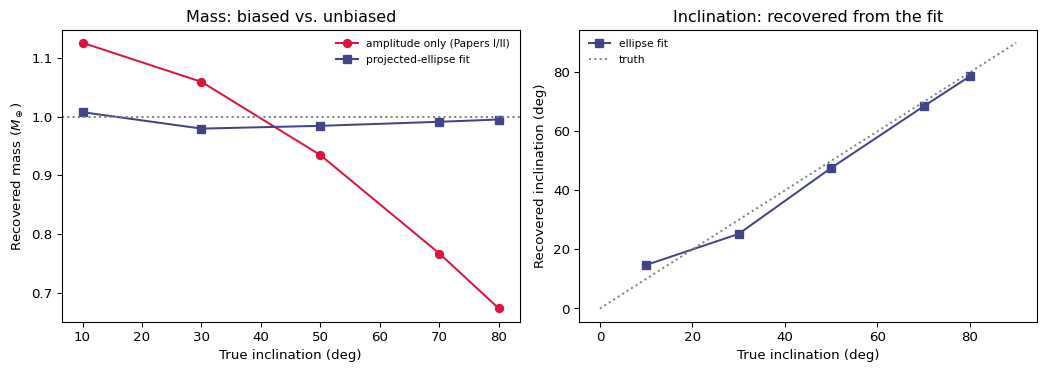

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(INCS, m_amp, "o-", color="crimson", label="amplitude only (Papers I/II)")
ax[0].plot(INCS, m_ell, "s-", color=VIR(0.2), label="projected-ellipse fit")
ax[0].axhline(1.0, ls=":", color="0.5"); ax[0].set_xlabel("True inclination (deg)")
ax[0].set_ylabel(r"Recovered mass ($M_\oplus$)"); ax[0].set_title("Mass: biased vs. unbiased")
ax[0].legend(frameon=False, fontsize=8)
ax[1].plot(INCS, i_ell, "s-", color=VIR(0.2), label="ellipse fit")
ax[1].plot([0, 90], [0, 90], ls=":", color="0.5", label="truth"); ax[1].set_xlabel("True inclination (deg)")
ax[1].set_ylabel("Recovered inclination (deg)"); ax[1].set_title("Inclination: recovered from the fit")
ax[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

The amplitude-only mass drifts with inclination — it is really measuring
(mass × projection factor). The ellipse fit returns the true mass at every
inclination **and** the inclination itself, to a few degrees.

## 2. Why it works: the planet's motion is the lever

How can a 1-D separation time series pin down a 2-D ellipse? Because the
star→planet direction φ(t) rotates as the planet orbits its star. Over a campaign
that covers a good fraction of the planet's orbit, the moon's reflex gets
projected onto *many* directions, and the four linear coefficients of the model
(Paper III Eq. 4) fix the full sky-projected ellipse: its semi-major axis is the
face-on reflex amplitude (→ mass), and its axis ratio is cos i (→ inclination).
The very thing that complicated detection — the planet-motion sidebands of
Tutorial 1 — is what makes characterization possible.

Let's draw the recovered ellipse for one inclination.

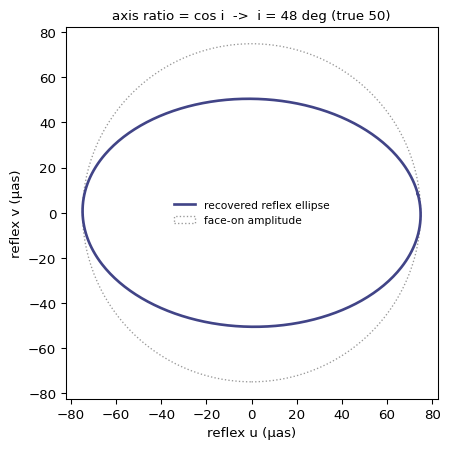

recovered: mass = 0.984 +/- 0.004 Mearth,  i = 47.6 deg,  face-on amplitude = 74.9 uas


In [4]:
INC_SHOW = 50.0
p = SimParams(moon_a=20.0, moon_mass=1.0, moon_inc=INC_SHOW, moon_ecc=0.0, **SEARCH)
d = run_trial(p, seed=SEED, return_diagnostics=True)["diag"]
rc = d["recoveries"][0]
td, phi = d["tdays"], np.arctan2(d["y_fit"], d["x_fit"])
w = 2 * np.pi / rc["sidereal"]
G = np.column_stack([np.cos(w * td) * np.cos(phi), np.cos(w * td) * np.sin(phi),
                     np.sin(w * td) * np.cos(phi), np.sin(w * td) * np.sin(phi), np.ones(td.size)])
ax_, ay_, bx_, by_ = np.linalg.lstsq(G, np.asarray(d["rres"]), rcond=None)[0][:4]

th = np.linspace(0, 2 * np.pi, 400)
u = (ax_ * np.cos(th) + bx_ * np.sin(th)) * UAS          # the reflex ellipse traced over one orbit
v = (ay_ * np.cos(th) + by_ * np.sin(th)) * UAS
smaj = rc["amp_mas"] * 1000.0
plt.figure(figsize=(4.8, 4.8))
plt.plot(u, v, color=VIR(0.2), lw=2, label="recovered reflex ellipse")
plt.gca().add_patch(plt.Circle((0, 0), smaj, fill=False, ec="0.6", ls=":", label="face-on amplitude"))
plt.gca().set_aspect("equal"); plt.xlabel("reflex u (µas)"); plt.ylabel("reflex v (µas)")
plt.title("axis ratio = cos i  ->  i = %.0f deg (true %.0f)" % (rc["inclination"], INC_SHOW), fontsize=10)
plt.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()
print("recovered: mass = %.3f +/- %.3f Mearth,  i = %.1f deg,  face-on amplitude = %.1f uas"
      % (rc["mass"], rc["mass_err"], rc["inclination"], smaj))

## 3. Limit 1: eccentric moons

The model assumes a circular moon orbit. An eccentric moon adds harmonics of the
orbital frequency that the circular fit does not capture, so the recovered mass is
biased low — by about 0.4 e² (Paper III Fig. 12): under 2% for e < 0.2, ~10% at
e = 0.5. Sweep the eccentricity at fixed inclination:

  e = 0.0 :  recovered mass = 0.984 Mearth   (bias -1.6%)
  e = 0.2 :  recovered mass = 0.969 Mearth   (bias -3.1%)
  e = 0.4 :  recovered mass = 0.925 Mearth   (bias -7.5%)


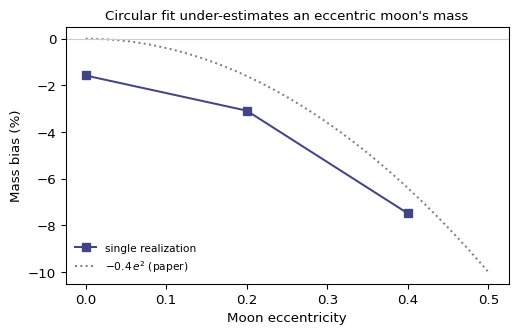

In [5]:
ECCS = [0.0, 0.2, 0.4] if FAST else [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
bias = []
for e in ECCS:
    p = SimParams(moon_a=20.0, moon_mass=1.0, moon_inc=50.0, moon_ecc=e, **SEARCH)
    rc = run_trial(p, seed=SEED, return_diagnostics=True)["diag"]["recoveries"][0]
    bias.append(rc["mass"] - 1.0)
    print("  e = %.1f :  recovered mass = %.3f Mearth   (bias %+.1f%%)" % (e, rc["mass"], 100 * bias[-1]))
plt.figure(figsize=(5.5, 3.6))
plt.plot(ECCS, 100 * np.array(bias), "s-", color=VIR(0.2), label="single realization")
ee = np.linspace(0, 0.5, 50); plt.plot(ee, -40 * ee ** 2, ls=":", color="0.5", label=r"$-0.4\,e^2$ (paper)")
plt.axhline(0, color="0.8", lw=0.8); plt.xlabel("Moon eccentricity"); plt.ylabel("Mass bias (%)")
plt.title("Circular fit under-estimates an eccentric moon's mass", fontsize=10)
plt.legend(frameon=False, fontsize=8); plt.tight_layout(); plt.show()

(A single realization scatters about the trend; the paper averages over periapsis
angle, orbital phase, and noise.) The fix is to add harmonics of ω as extra linear
terms. Tutorial 2 showed the other face of this same effect: for a *strong*
eccentric moon, the matched filter can flag the missing harmonic as a spurious
companion at half the moon's period.

## 4. Limit 2: how much of the planet's orbit you cover

The lever in §2 only works if φ(t) actually sweeps. For a long-period planet whose
position angle barely changes over the campaign, the ellipse loses its constraint:
the moon is still *detected*, but the inclination scatter grows and the mass drifts
high once less than ~a quarter of the planet's orbit is covered (Paper III Fig. 11).
You can explore this by raising `planet_a` in `SimParams` (a wider planet orbit
means a longer period and less coverage in five years); that sweep is
`paper/make_planetperiod_fig.py`.

## Take-aways

* An amplitude-only mass carries the projection factor; the ellipse fit removes it
  and returns the inclination for free.
* The planet's own orbital motion is what makes a 1-D measurement constrain a 2-D
  reflex — detection's nuisance is characterization's lever.
* Trust the characterization for near-circular moons around planets whose orbit
  the campaign appreciably covers.

**Paper config:** `FAST = False` reproduces Paper III Fig. 1 and Table 4.